## step 1 Import the dataset

In [27]:
import matplotlib.pyplot as plt
import tensorflow as tf

In [18]:
import tensorflow as tf
import numpy as np
(x_train,y_train),(x_test,y_test)= tf.keras.datasets.mnist.load_data() # in keras ...no need the train test split algorithm......its automaticaly it will divied
print("training data",x_train.shape)
print("training answer",y_train.shape)
print("testing data",x_test.shape)
print("testing answer",y_test.shape)

training data (60000, 28, 28)
training answer (60000,)
testing data (10000, 28, 28)
testing answer (10000,)


In [43]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
(train_x, train_y), (test_x, test_y)=tf.keras.datasets.mnist.load_data()
x=tf.concat([train_x, test_x], axis=0).numpy()
y=tf.concat([train_y, test_y], axis=0).numpy()
print(x.shape)
print(y.shape)
#x_train,x_test,y_train,y_test=train_test_split(x,
                                         #      y,
                                             #  test_size=0.2,
                                             #  random_state=42)

print("using the t")
print(x_train.shape)
print(x_test.shape)
print(y_test.shape)

(70000, 28, 28)
(70000,)
hi
(56000, 28, 28)
(14000, 28, 28)
(14000,)


## step 2 ACCESSING THE VALUES

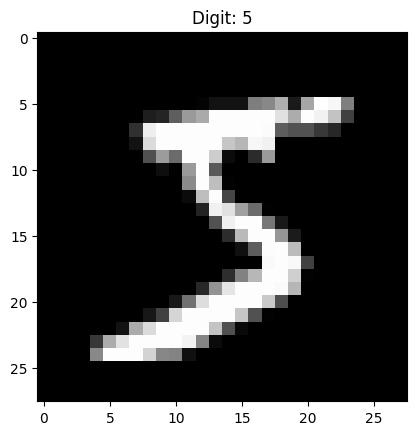

In [7]:
plt.imshow(x_train[0],cmap="gray")#x_train[0] → first image
plt.title(f"Digit: {y_train[0]}")# correct label of that image
axis="off" # in output come some number ...remove that numbers
plt.show()

Text(0.5, 1.0, 'Digit: 0')

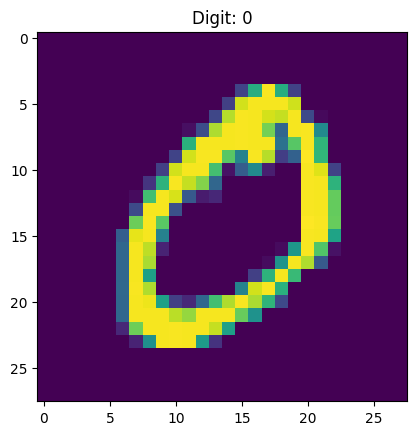

In [11]:
plt.imshow(x_train[1])
plt.title(f"Digit: {y_train[1]}")

Text(0.5, 1.0, 'Digit: 5')

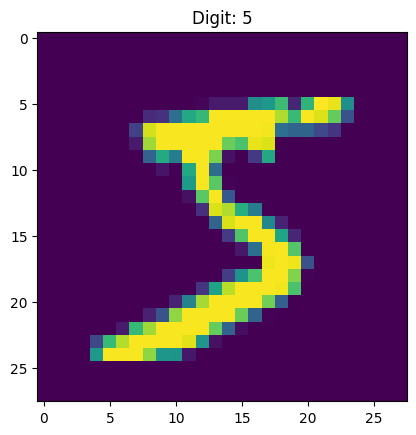

In [38]:
plt.imshow(x_train[0])
plt.title(f"Digit: {y_train[0]}")

## Step 3 — Normalize the pixel values 🔢

In [19]:
x_train=x_train / 255.0
x_test=x_test/255.0
print(x_train.min())
print(x_train.max())

0.0
1.0


## Step 4 — Add the channel dimension

In [20]:
x_train.shape

(60000, 28, 28)

In [25]:
x_train=x_train.reshape(-1,28,28,1)
x_test=x_test.reshape(-1, 28, 28, 1)
x_train.shape
x_test.shape

(10000, 28, 28, 1)

In [26]:
x_test.shape

(10000, 28, 28, 1)

## Step 5 — Build the CNN 🧠

In [33]:
model=tf.keras.Sequential([

    tf.keras.layers.Input(shape=(28,28,1)),
        
    tf.keras.layers.Conv2D(32,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),

    tf.keras.layers.Dense(10, activation="softmax"),

])

model.summary()
    


    
    

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Step 6 — Compile the CNN ⚙️

In [34]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

In [35]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 44s 22ms/step - accuracy: 0.9572 - loss: 0.1391 - val_accuracy: 0.9848 - val_loss: 0.0527
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 43s 24ms/step - accuracy: 0.9859 - loss: 0.0463 - val_accuracy: 0.9895 - val_loss: 0.0419
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - accuracy: 0.9909 - loss: 0.0291 - val_accuracy: 0.9897 - val_loss: 0.0404
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 42s 23ms/step - accuracy: 0.9929 - loss: 0.0211 - val_accuracy: 0.9885 - val_loss: 0.0410
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.9946 - loss: 0.0165 - val_accuracy: 0.9907 - val_loss: 0.0408


In [36]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9906 - loss: 0.0298
Test Loss: 0.02978775091469288
Test Accuracy: 0.9905999898910522


## Step 7 — Make an actual prediction 🎯

In [92]:

index = 0

prediction = model.predict(x_test[index:index+2])

predicted_digit = np.argmax(prediction)

print("Predicted digit:", predicted_digit)
print("Actual digit:", y_test[index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
Predicted digit: 7
Actual digit: 7


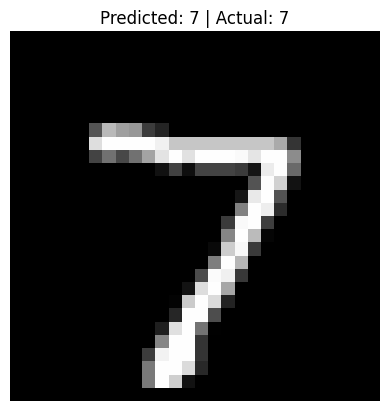

In [45]:

plt.imshow(x_test[index].squeeze(), cmap="gray")
plt.title(f"Predicted: {predicted_digit} | Actual: {y_test[index]}")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
[[3.5672503e-09 9.9998903e-01 9.7007691e-09 2.0544397e-12 1.8174794e-06
  9.1843102e-09 5.4308362e-08 7.2228596e-07 8.3259447e-06 2.3442213e-09]
 [9.9999654e-01 1.1047952e-10 1.7824989e-08 5.2532895e-10 1.0415932e-10
  9.2105662e-10 3.4934105e-06 2.5044655e-09 7.5229574e-09 3.9449040e-09]
 [8.4984813e-13 5.9354598e-11 6.3105680e-11 4.7905521e-16 9.9999571e-01
  1.1707385e-14 4.1714626e-10 7.6832351e-12 2.9477609e-09 4.2760184e-06]]
10


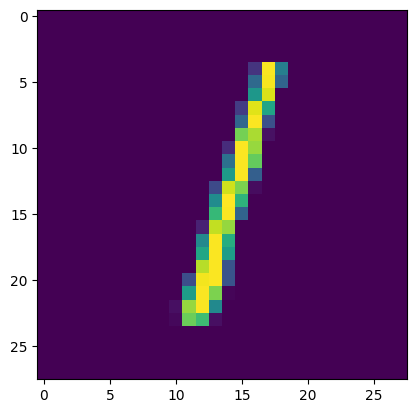

In [61]:
prediction=model.predict(x_test[2:5])
prediction_digt=np.argmax(prediction)
print(prediction)
print(prediction_digt)
plt.imshow(x_test[2])

<function matplotlib.pyplot.show(close=None, block=None)>

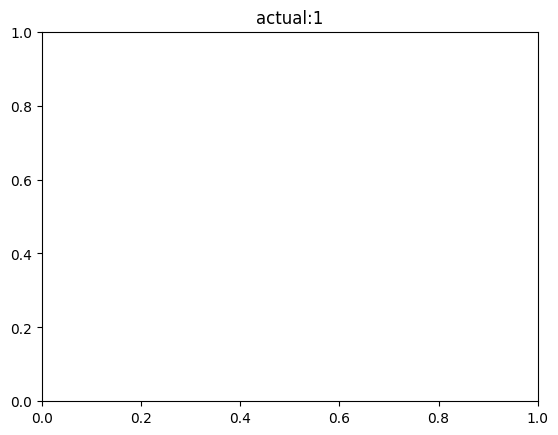

In [60]:
plt.title(f"actual:{y_test[2]}")
plt.show

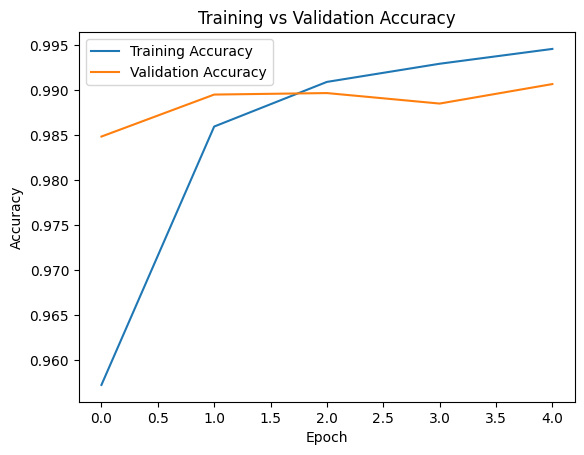

In [62]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Training Accuracy")# it take automaticalyy accuracy values 
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")# it take automaticalyy validation_accuracy values 

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

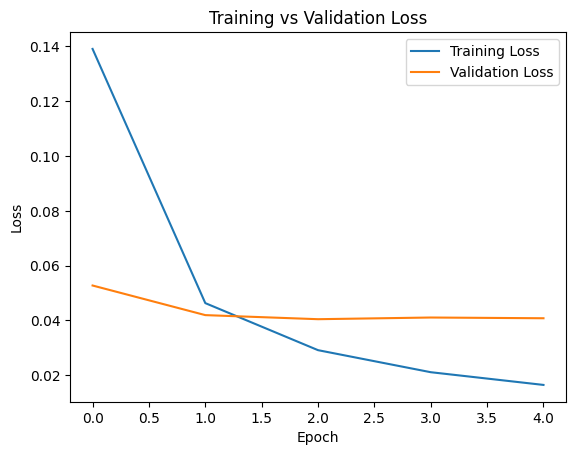

In [63]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

## IMPORT THE NEW IMAGE FOR THE PREDICTION

In [71]:
from PIL import Image

img = Image.open("my_digit.png")

print("Original size:", img.size)
print("Original mode:", img.mode)

Original size: (1254, 1254)
Original mode: RGB


In [73]:
img = img.convert("L")

In [74]:
print(img.mode)

L


In [75]:
img = img.resize((28, 28))

In [77]:
print(img.size)

(28, 28)


## Convert image to NumPy array

In [78]:
num_array=np.array(img)

In [80]:
print(num_array.min())
print(num_array.max())

0
255


In [81]:
num_array=num_array/255.0

In [82]:
print(num_array.min())
print(num_array.max())

0.0
1.0


In [83]:
num_array.shape

(28, 28)

# we want 1 ...the cnn only allow

In [90]:
num_array=num_array.reshape(1,28,28,1)

In [91]:
num_array.shape

(1, 28, 28, 1)

In [ ]:
1    → one image
28   → height
28   → width
1    → grayscale channel

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
predicted 7


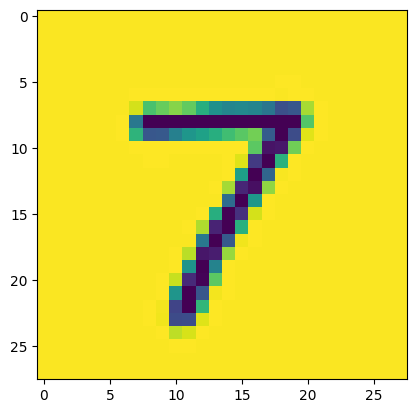

In [106]:
prediction=model.predict(num_array)
pre_digit=np.argmax(prediction)
print("predicted",pre_digit)
plt.imshow(num_array[0])
plt.show()